In [70]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## Introduction

### Benchmarks:
- Moving AVG.
- Momentum
- AR(1) (univariate models) (ARMA)
- PCA (k-factor model) -> maybe VAR on the PCA (My part)
- AR-GARCH(1,1)

### EDA:
- 

In [71]:
df = pd.read_csv("df_train.csv",
                 parse_dates=["date"],
                 index_col="date")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100600 entries, 2010-01-04 to 2013-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  100600 non-null  object 
 1   open    100600 non-null  float64
 2   close   100600 non-null  float64
 3   low     100600 non-null  float64
 4   high    100600 non-null  float64
 5   volume  100600 non-null  float64
dtypes: float64(5), object(1)
memory usage: 5.4+ MB


,symbol,open,close,low,high,volume
date,,,,,,
2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275
2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257
2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820
2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991


In [72]:
df_grouped = df.groupby(["symbol", "date"]).mean()
df_close = df_grouped.loc[:, "close"]
#df_close.info()

# reshape into wide
df_close_wide = df_close.unstack(level=0)
#df_close_wide.info()

# log-returns
rets = np.log(df_close_wide/df_close_wide.shift(1)).dropna()
#rets.info()

# Training set: years 2010-2011 (503 days)
rets_train = rets.loc["2010":"2011", ]
#rets_train.info()

rets_train.columns = rets_train.columns.get_level_values(-1)
rets_train.head()

symbol,ACTS,AMWD,ARV,BBY,BCDM,BZK,BZQM,CDM,CDRX,CLYQ,...,WYLR,WZB,XBRQ,XFG,XPT,XTG,YPN,YRD,YVNL,ZQN
date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,-0.008048,-0.018427,-0.002734,-0.006452,-0.011847,-0.002646,-0.022421,-0.008445,-0.014345,-0.014135,...,-0.008962,-0.014766,-0.003104,0.001000,-0.009486,-0.012850,-0.012941,-0.001914,-0.006645,-0.002381
2010-01-06,0.000673,-0.021693,-0.021030,-0.016314,-0.015666,-0.012663,-0.017201,0.006149,-0.015326,-0.003565,...,-0.012076,-0.016667,-0.014614,-0.032490,-0.020253,0.004130,-0.007991,-0.015444,-0.030459,-0.022736
2010-01-07,-0.010826,-0.025168,0.016089,-0.013245,-0.011647,-0.003359,-0.003357,-0.000767,-0.026606,-0.014389,...,0.010574,0.001679,-0.011634,-0.022966,0.039943,0.003086,0.003640,-0.005854,-0.010363,-0.005591
2010-01-08,-0.020619,-0.010550,-0.023950,-0.023610,-0.004804,0.000000,-0.014546,-0.010794,-0.027333,0.010811,...,-0.013616,-0.011814,-0.018251,-0.030013,-0.020512,-0.006182,-0.013904,-0.005888,-0.042560,-0.029152
2010-01-11,0.010363,0.012048,0.008420,-0.013746,0.004804,-0.017652,0.021446,0.013857,-0.007362,0.007143,...,0.001522,-0.005106,-0.023015,-0.014799,-0.004451,0.007722,0.011722,-0.015873,-0.025689,-0.010882


explained variances (in %): [55.82190905 20.39230228]


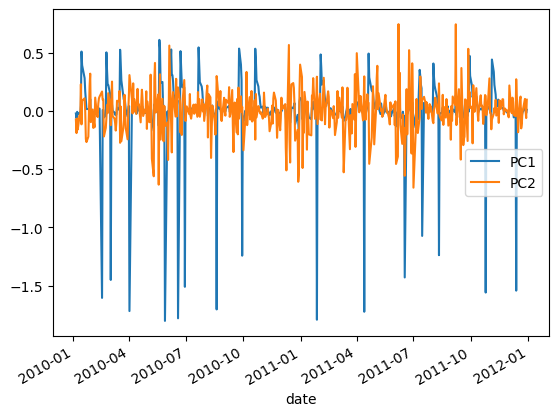

In [73]:
# PCA iteration
pca = PCA(n_components=2)
pcs = pca.fit_transform(rets_train)
pca_fit = pca.fit(rets_train)

pcs_df = pd.DataFrame(
    pcs,
    index=rets_train.index,
    columns=['PC1', 'PC2']
)

pcs_df.plot()

print(f"explained variances (in %): {pca_fit.explained_variance_ratio_*100}")

In [74]:
pca_full = PCA(n_components=99)
pca_full_fit = pca_full.fit(rets_train)
pcs_full = pca_full.fit_transform(rets_train)
pca_full_df = pd.DataFrame(pcs_full,
                           index = rets_train.index,
                           columns=[f"PCA{i}" for i in range(1,np.shape(pcs_full)[1]+1)])
pca_full_df.head()

X = np.cumsum(pca_full_fit.explained_variance_ratio_)

first 1 components explain 55.82% of the in-sample variation
first 2 components explain 76.21% of the in-sample variation
first 3 components explain 80.76% of the in-sample variation
first 4 components explain 84.74% of the in-sample variation
first 5 components explain 87.48% of the in-sample variation
first 6 components explain 88.5% of the in-sample variation
first 7 components explain 89.25% of the in-sample variation
first 8 components explain 89.95% of the in-sample variation
first 9 components explain 90.57% of the in-sample variation
first 10 components explain 91.14% of the in-sample variation


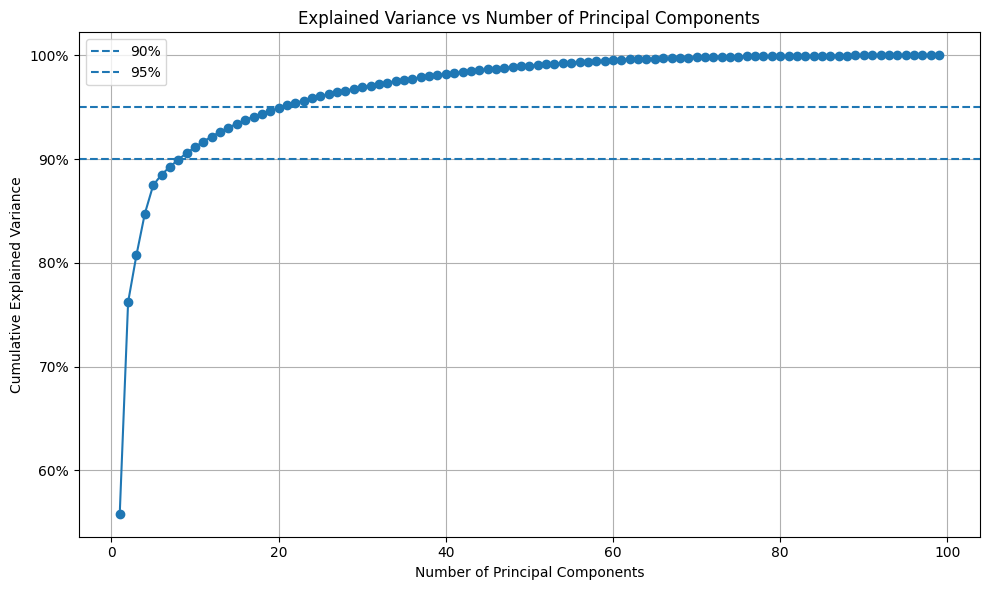

In [75]:
# PCs variations
# the first 4 components explain about 85% of the in-sample variation -> compare predictive performance of 1-5 PCs on the validation set?
for i in range(1,11):
    print(f"first {i} components explain {np.round(X[i-1]*100, 2)}% of the in-sample variation")


n_components = np.arange(1, len(X) + 1)

plt.figure(figsize=(10, 6))

plt.plot(n_components, X, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Principal Components')

# Optional: percentage formatting
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

# Optional: horizontal threshold lines
plt.axhline(y=0.9, linestyle='--', label='90%')
plt.axhline(y=0.95, linestyle='--', label='95%')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 2-factor model because of noisy data